# Notebook 02: Signal Preprocessing

**Project:** ECG Arrhythmia Classification with MIT-BIH  
**Author:** Qide Zhengzhao  
**Date:** 23 July 2026  

---

## Objective of this notebook

Raw ECG signals recorded in clinical or ambulatory settings are contaminated by several types of noise that can corrupt the morphological features used for arrhythmia classification. Before any machine learning model can be applied, the signal must be cleaned and individual heartbeats must be extracted.

This notebook covers three stages:

1. **Baseline wander removal and high-frequency noise filtering** using a zero-phase Butterworth bandpass filter
2. **Beat segmentation** centered on annotated R-peaks following the AAMI/ANSI EC57 standard
3. **Label mapping** from raw MIT-BIH annotation codes to the five AAMI superclasses (N, S, V, F, Q)

Each decision is justified with clinical and signal processing reasoning.

All design decisions in this notebook are grounded in the empirical
findings of Notebook 01: the filter cutoffs address the noise sources
identified in Section 9, the segmentation window is sized to capture
the P-QRS-T components characterized in Section 6, and the DS1/DS2
split is motivated by the inter-patient variability demonstrated in
Section 8.

---

## Why preprocessing matters in biomedical signals

In typical computer vision or NLP tasks, the raw input (an image, a token) is already a stable, well-defined object. ECG signals are fundamentally different: they are continuous, non-stationary, and recorded under variable conditions (patient movement, electrode impedance, electrical interference from hospital equipment). 

A model trained on unfiltered ECG will learn to distinguish noise artifacts as much as cardiac morphology, a problem that affects generalization directly, since noise patterns vary between patients, recording sessions, and electrode placements.

The preprocessing pipeline defined here follows the approach used in the majority of peer-reviewed ECG classification papers, and specifically the inter-patient evaluation protocol defined in de Chazal et al. (2004) [[1]](#references), which remains the benchmark for MIT-BIH classification.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import wfdb
from scipy.signal import butter, filtfilt, freqz
from collections import Counter
import warnings
warnings.filterwarnings('ignore')
from src.utils_data import get_valid_records 
from src.preprocessing import bandpass_filter, segment_beats, process_record_list

# ── Plot styling ───────────────────────────────────────────────────────────––––––––––––––––––
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
#──────────────────────────────────────────────────────────────────────────────────────────────

# ── Constants ────────────────────────────────────────────────────────────────────────────────
FS = 360                                        # Sampling frequency (Hz), fixed for all MIT-BIH records
WINDOW_BEFORE = 90                              # 90 samples before R-peak = 250 ms
WINDOW_AFTER = 110                              # 110 samples after R-peak = ~306 ms
BEAT_LENGTH = WINDOW_BEFORE + WINDOW_AFTER      # Total: 200 samples ≈ 556 ms per beat
#──────────────────────────────────────────────────────────────────────────────────────────────


# –– All 48 MIT-BIH record names ─────────────────────────────────────────────––––––––––––––––––
DATA_PATH = '../data/raw/'
ALL_RECORDS, incomplete_records = get_valid_records(DATA_PATH)
#──────────────────────────────────────────────────────────────────────────────────────────────


print(f"Configuration loaded. Total records: {len(ALL_RECORDS)}")
print(f"Beat window: {WINDOW_BEFORE} + {WINDOW_AFTER} = {BEAT_LENGTH} samples ({BEAT_LENGTH/FS*1000:.0f} ms)")

Configuration loaded. Total records: 48
Beat window: 90 + 110 = 200 samples (556 ms)


### Segmentation window justification

The window of 90 + 110 samples (556 ms total) is chosen based on the temporal anatomy of a normal cardiac cycle at resting heart rate (60–80 bpm), following standard ECG reference values [[2]](#references).

**Converting samples to milliseconds:**

$$\text{ms} = \frac{\text{samples}}{\text{FS}} \times 1000$$

$$\frac{90}{360} \times 1000 = 250 \text{ ms (before)}$$

$$\frac{110}{360} \times 1000 \approx 306 \text{ ms (after)}$$

$$\text{Total} = \frac{200}{360} \times 1000 \approx 556 \text{ ms per beat}$$

| Component | Typical duration | Position relative to R-peak |
|---|---|---|
| P wave | 80–100 ms | ends ~120 ms before R-peak |
| PR interval | 120–200 ms | from P onset to QRS onset |
| QRS complex | 60–100 ms | centered on R-peak (±50 ms) |
| ST segment | 80–120 ms | starts ~50 ms after R-peak |
| T wave | 160–200 ms | peak ~200–250 ms after R-peak |

**Before the R-peak (250 ms):** the P wave onset occurs approximately 120–200 ms before the R-peak. 250 ms before captures the full P wave with margin.

**After the R-peak (306 ms):** the T wave peak occurs approximately 200–250 ms after the R-peak. 306 ms after captures the T wave completely including its descent.

**Limitation at high heart rates:** at heart rates above 100 bpm (R-R interval < 600 ms), adjacent beat windows begin to overlap slightly (~44 ms). This affects the P wave of the following beat but not the QRS morphology, which drives classification. This window follows the standard defined in de Chazal et al. (2004) [[1]](#references).

---
## 1. Imports, setup, and constants

The cell above defines all constants used throughout this notebook.
The segmentation window parameters (`WINDOW_BEFORE`, `WINDOW_AFTER`)
require special justification because their values are not arbitrary —
they are derived from the temporal anatomy of the cardiac cycle.

## 2. Understanding the noise sources in ECG

Before designing the filter, it is important to identify what we are removing and why. The three main noise sources in ambulatory ECG recordings are: [[3]](#references)

| Noise type | Frequency range | Cause | Visual appearance |
|---|---|---|---|
| Baseline wander | 0 – 0.5 Hz | Respiration, electrode movement | Slow drift of the isoelectric line |
| Powerline interference | 50 / 60 Hz | Electrical grid coupling | Regular oscillation superimposed on signal |
| Muscle artifact (EMG) | > 100 Hz | Patient movement or shivering | High-frequency irregular noise |

The solution is a **bandpass filter** that preserves frequencies between 0.5 and 40 Hz, which contains all clinically relevant ECG information (QRS complex energy peaks between 10–25 Hz; P and T waves contain energy below 10 Hz). [[3]](#references)

### Why Butterworth specifically?

Several filter families exist (Chebyshev, Elliptic, Bessel). The **Butterworth filter** is standard in ECG processing for two reasons: [[4]](#references)
1. **Maximally flat passband**: it does not distort amplitudes within the passband, which is critical because the amplitude of the R-peak is a diagnostic feature.
2. **Monotonic frequency response**: no ripple in either passband or stopband, which prevents ringing artifacts near the QRS complex.

We use `filtfilt` (zero-phase filtering) instead of `lfilter` to avoid any phase shift, which would displace the R-peak position and corrupt interval measurements. [[1]](#references)

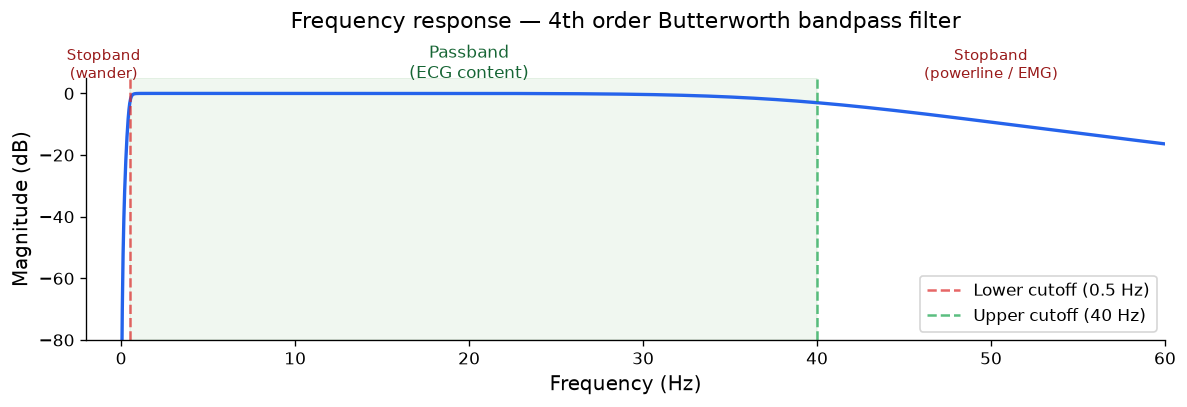

In [2]:
# –– Visualize the frequency response of our filter ––––––––––––––––––––––––––––––––––––––––––––
nyquist = FS / 2
b, a    = butter(4, [0.5/nyquist, 40/nyquist], btype='band')
w, h    = freqz(b, a, worN=8000, fs=FS)

fig, ax = plt.subplots(figsize=(10, 3.5))

ax.plot(w, 20 * np.log10(np.abs(h) + 1e-10), color='#2563EB', linewidth=2)
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


# –– Passband shading ––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
ax.axvspan(0.5, 40, alpha=0.06, color='green')
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


# –– Cutoff lines –––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
ax.axvline(0.5, color='#DC2626', linestyle='--', alpha=0.7, label='Lower cutoff (0.5 Hz)')
ax.axvline(40,  color='#16A34A', linestyle='--', alpha=0.7, label='Upper cutoff (40 Hz)')
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


# –– Labels –––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
ax.text(-1, 5, 'Stopband\n(wander)',          ha='center', color='#991B1B', fontsize=9)
ax.text(20,  5, 'Passband\n(ECG content)',     ha='center', color='#166534', fontsize=10)
ax.text(50,  5, 'Stopband\n(powerline / EMG)', ha='center', color='#991B1B', fontsize=9)
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


# –– Axes and title –––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
ax.set_xlim(-2, 60)
ax.set_ylim(-80, 5)
ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Magnitude (dB)', fontsize=12)
ax.set_title('Frequency response — 4th order Butterworth bandpass filter', fontsize=13, pad=30)
ax.legend(fontsize=10)
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


plt.subplots_adjust(top=0.85)
plt.tight_layout()
plt.savefig('../results/figures/02_02_filter_response.png', bbox_inches='tight')
plt.show()

### Reading the frequency response plot

The plot shows the **magnitude response** of the filter in decibels (dB) across the frequency spectrum (0–60 Hz):

- **Passband (0.5–40 Hz):** magnitude close to 0 dB, signals in this range pass through with minimal distortion. All cardiac components (P wave, QRS, T wave) fall here.
- **Stopband below 0.5 Hz:** magnitude drops steeply, baseline wander is attenuated before it reaches the signal.
- **Stopband above 40 Hz:** magnitude drops steeply, powerline interference (50/60 Hz) and EMG artifacts are removed.
- **−3 dB point:** by convention, the cutoff frequency is defined as the point where the filter reduces signal power by half (−3 dB). The cutoff frequencies (0.5 Hz and 40 Hz) are marked by the dashed vertical lines, at these exact frequencies the magnitude is −3 dB.

## 3. Visual inspection: raw vs. filtered signal

Before running the pipeline on all 48 records, we visually verify that the filter behaves correctly on a representative sample. Record 116 is chosen because it contains significant baseline wander and several PVC beats, making it a good stress test for the preprocessing.

**What to look for:**
- The isoelectric line (flat baseline between beats) should become horizontal after filtering
- The morphology of the QRS complex (sharp peak) should be preserved
- No ringing artifacts should appear immediately before or after the QRS

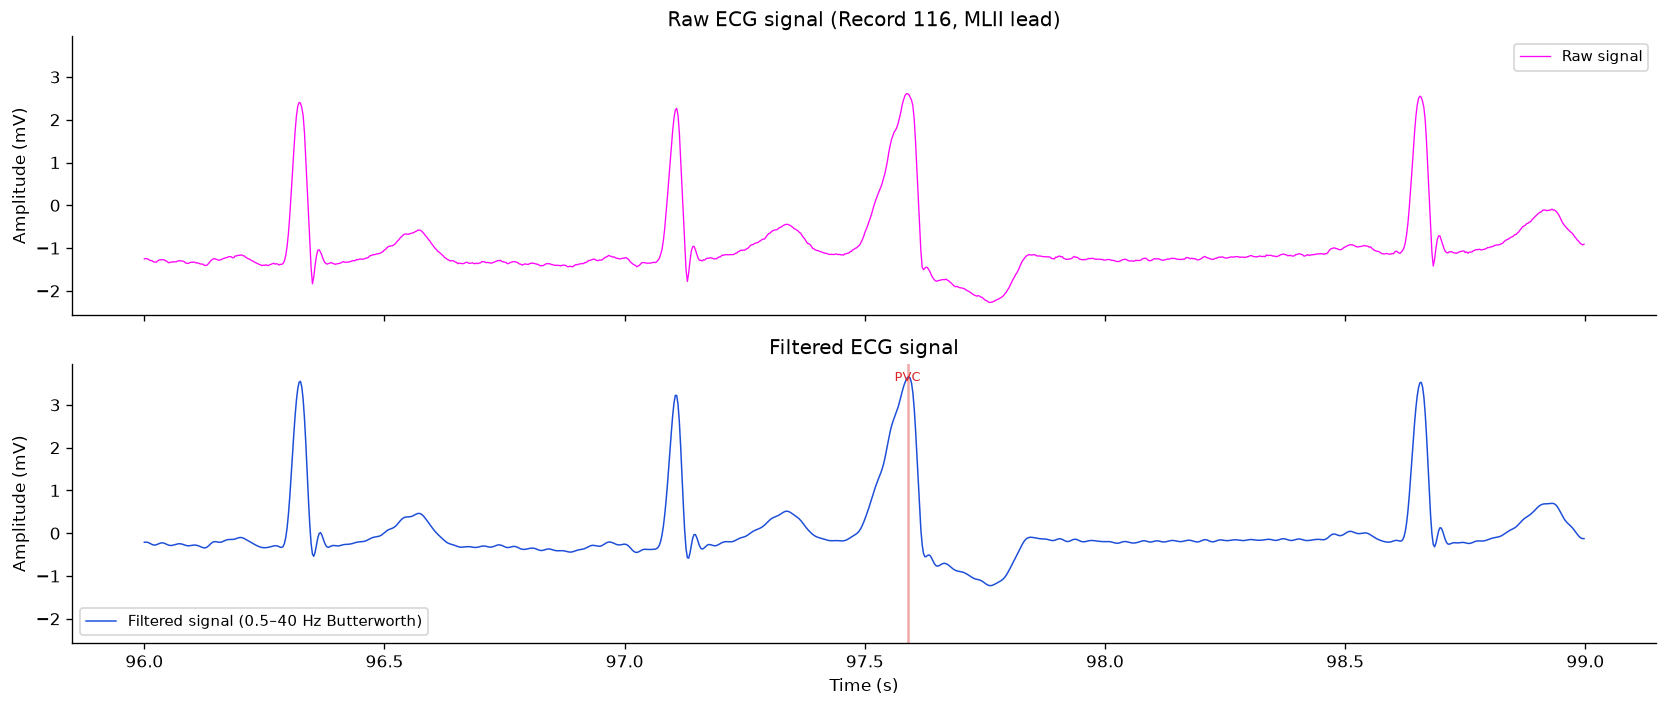

PVC beats detected in this window: 1


In [3]:
# –– Load a sample record for visual inspection ––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
sample_record_1 = '116'
record = wfdb.rdrecord(DATA_PATH + sample_record_1, sampfrom=0, sampto=FS * 180)  # 20 seconds
annotation = wfdb.rdann(DATA_PATH + sample_record_1, 'atr', sampfrom=0, sampto=FS * 180)
#–––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


signal_raw = record.p_signal[:, 0]              # Channel 0 = MLII (standard lead for arrhythmia detection)
signal_filtered = bandpass_filter(signal_raw)
time = np.arange(len(signal_raw)) / FS          # Convert samples to seconds


# –– Plot raw vs filtered — 3 second window ––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
t_start, t_end = 96, 99
s_start, s_end = t_start * FS, t_end * FS

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True, sharey=True)

axes[0].plot(time[s_start:s_end], signal_raw[s_start:s_end], color='#FF06FB', linewidth=0.8, label='Raw signal')
axes[0].set_title(f'Raw ECG signal (Record {sample_record_1}, MLII lead)', fontsize=12)
axes[0].set_ylabel('Amplitude (mV)')
axes[0].legend(fontsize=9)

axes[1].plot(time[s_start:s_end], signal_filtered[s_start:s_end],color='#1D4ED8', linewidth=0.9, label='Filtered signal (0.5–40 Hz Butterworth)')
axes[1].set_title('Filtered ECG signal', fontsize=12)
axes[1].set_ylabel('Amplitude (mV)')
axes[1].set_xlabel('Time (s)')
axes[1].legend(fontsize=9)
#–––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


# –– Mark PVC beats in filtered signal (they appear as wide, aberrant complexes) –––––––––––––––––––––––––––––
pvc_samples = [s for s, sym in zip(annotation.sample, annotation.symbol) 
               if sym == 'V' and s_start <= s <= s_end]

for s in pvc_samples:
    axes[1].axvline(s/FS, color='#DC2626', alpha=0.4, linewidth=1.5)
    axes[1].text(s/FS, axes[1].get_ylim()[1]*0.9, 'PVC', color='#DC2626', fontsize=8, ha='center')
#–––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


plt.tight_layout()
plt.savefig('../results/figures/02_03_raw_vs_filtered.png', bbox_inches='tight')
plt.show()
print(f"PVC beats detected in this window: {len(pvc_samples)}")

### What this figure shows

Comparing the two panels reveals the primary effect of the bandpass filter:

**Baseline correction:** the raw signal (grey) has its isoelectric line displaced downward to approximately −1 to −2 mV throughout the window. After filtering (blue), the baseline is centered at 0 mV. This is the baseline wander component (< 0.5 Hz) being removed by the highpass cutoff of the filter.

**QRS amplitude is preserved:** the R-peak amplitudes in the filtered signal (~3 mV) are comparable to those in the raw signal, confirming that the Butterworth filter does not distort the passband (0.5–40 Hz).

**PVC beats are marked in red.** At this temporal scale (3 seconds, ~4 beats visible) the morphological difference between PVC and normal beats is subtle. A clearer morphological comparison between beat types is shown in Notebook 01, Section 6, where individual beats are plotted centered on their R-peak.

**Note on ringing artifacts:** no oscillations are visible before or after the QRS complexes, which confirms that `filtfilt` (zero-phase forward-backward filtering) is working correctly. A causal filter (`lfilter`) would introduce visible pre-ringing before each QRS peak.

## 4. AAMI label mapping

The AAMI EC57 label mapping defined in the setup cell groups the 15
MIT-BIH beat symbols into 5 superclasses (N, S, V, F, Q). This mapping
was introduced and justified in detail in Notebook 01, Section 3.

Here we verify that the mapping loaded correctly and confirm the
number of recognized symbols before running the segmentation pipeline.

In [4]:
# –– AAMI EC57 label mapping ––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
AAMI_MAP = {
    # Normal beats
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    # Supraventricular ectopic beats
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    # Ventricular ectopic beats
    'V': 'V', 'E': 'V',
    # Fusion beats
    'F': 'F',
    # Paced and unclassifiable beats
    '/': 'Q', 'f': 'Q', 'Q': 'Q'
}
#–––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


CLASS_COLORS = {'N': '#3B82F6', 'S': '#F59E0B', 'V': '#EF4444', 'F': '#8B5CF6', 'Q': '#FF06FB'}
CLASS_NAMES = {'N': 'Normal', 'S': 'Supraventricular', 'V': 'Ventricular (PVC)', 'F': 'Fusion', 'Q': 'Unknown/Paced'}

print("AAMI label mapping loaded.")
print(f"Total beat symbols recognized: {len(AAMI_MAP)}")
print(f"Output classes: {list(set(AAMI_MAP.values()))}")

AAMI label mapping loaded.
Total beat symbols recognized: 15
Output classes: ['S', 'F', 'Q', 'V', 'N']


## 5. Beat segmentation

The core operation in ECG preprocessing for classification is **beat segmentation**: cutting the continuous signal into individual heartbeat windows, each centered on the R-peak (the tallest point of the QRS complex).

The segmentation window (90 + 110 samples = 556 ms) was justified in section 1. Here we implement it and verify the output on a single record before running the full pipeline.

### Edge handling

The first and last few beats of a record may not have enough signal before or after to fill the window. These are discarded silently they represent <1% of the dataset and are often of lower quality (electrode settling at the start, movement artifacts at the end).

In [5]:
# –– Test on a single record first ––––––––––––––––––––––––––––––––––
sample_record_2 = '100'
print(f"Testing segmentation on record {sample_record_2}:")
record_test = wfdb.rdrecord(DATA_PATH + sample_record_2)
ann_test = wfdb.rdann(DATA_PATH + sample_record_2, 'atr')
signal_test = bandpass_filter(record_test.p_signal[:, 0])
beats_test, labels_test = segment_beats(signal_test, ann_test)
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


print(f"  Beat matrix shape: {beats_test.shape}")
print(f"  Label distribution: {Counter(labels_test)}")

Testing segmentation on record 100:
  Beat matrix shape: (2271, 200)
  Label distribution: Counter({'N': 2237, 'S': 33, 'V': 1})


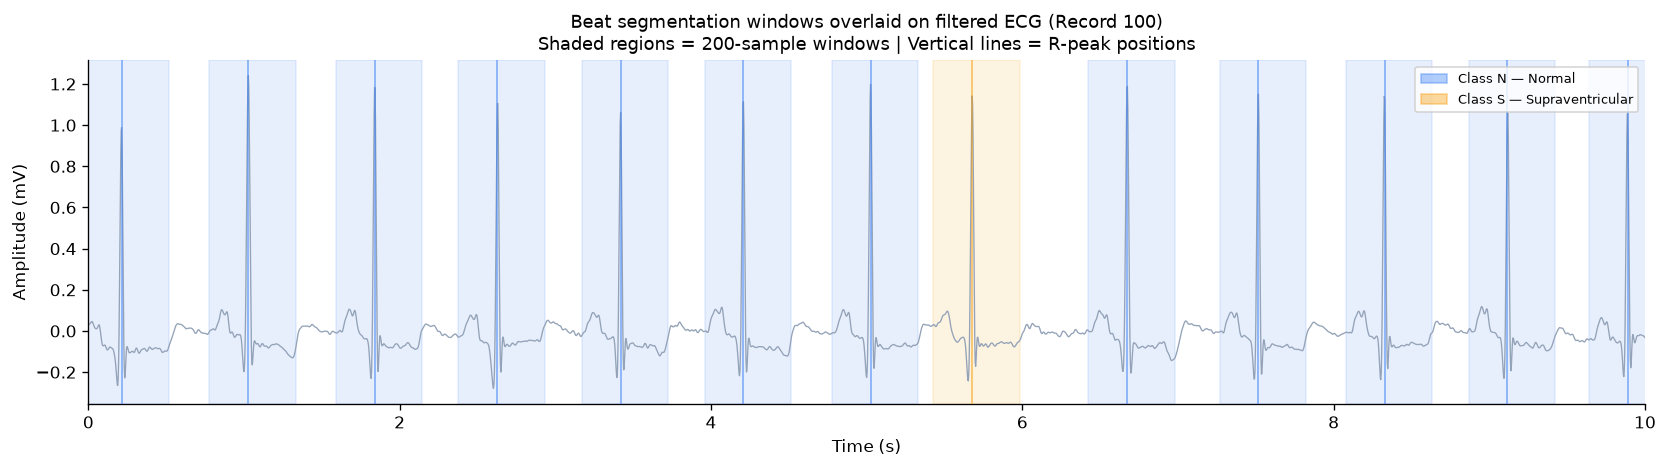

In [6]:
# ── Visualize segmentation: show beat windows overlaid on the signal ────────
# This verifies that the window is correctly centered on each R-peak
# and that the full P-QRS-T complex is captured within the window boundaries.

record_viz = wfdb.rdrecord(DATA_PATH + '100', sampfrom=0, sampto=FS * 10)
ann_viz    = wfdb.rdann(DATA_PATH + '100', 'atr', sampfrom=0, sampto=FS * 10)
sig_viz    = bandpass_filter(record_viz.p_signal[:, 0])
time_viz   = np.arange(len(sig_viz)) / FS

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(time_viz, sig_viz, color='#94A3B8', linewidth=0.8, zorder=2)

# Shade each beat window and mark the R-peak
for sample, symbol in zip(ann_viz.sample, ann_viz.symbol):
    if AAMI_MAP.get(symbol) is None:
        continue
    start = (sample - WINDOW_BEFORE) / FS
    end   = (sample + WINDOW_AFTER)  / FS
    color = CLASS_COLORS[AAMI_MAP[symbol]]

    # Shade the segmentation window
    ax.axvspan(start, end, alpha=0.12, color=color, zorder=1)
    # Mark the R-peak
    ax.axvline(sample / FS, color=color, alpha=0.6, linewidth=1, zorder=3)

# Build legend
legend_patches = [
    mpatches.Patch(color=CLASS_COLORS[c], alpha=0.4, label=f'Class {c} — {CLASS_NAMES[c]}')
    for c in ['N', 'S', 'V', 'F', 'Q']
    if any(AAMI_MAP.get(s) == c for s in ann_viz.symbol)
]
ax.legend(handles=legend_patches, fontsize=8, loc='upper right')
ax.set_xlabel('Time (s)', fontsize=10)
ax.set_ylabel('Amplitude (mV)', fontsize=10)
ax.set_title('Beat segmentation windows overlaid on filtered ECG (Record 100)\n'
             'Shaded regions = 200-sample windows | Vertical lines = R-peak positions',
             fontsize=11)
ax.set_xlim(0, 10)
plt.tight_layout()
plt.savefig('../results/figures/02_05_segmentation_windows.png', bbox_inches='tight')
plt.show()

In [7]:
# ── Sanity checks on the segmented beats ───────────────────────────────────
# These verify that the segmentation output is numerically correct
# before running the full pipeline on all 48 records.

print("Sanity checks on record 100 segmentation:")
print()

# Check 1: beat matrix shape
expected_beats  = sum(1 for s in ann_test.symbol if s in AAMI_MAP)
extracted_beats = beats_test.shape[0]
print(f"  [1] Beat count   : {extracted_beats} extracted / {expected_beats} annotated "
      f"({'OK' if extracted_beats <= expected_beats else 'ERROR'})")

# Check 2: beat length
print(f"  [2] Beat length  : {beats_test.shape[1]} samples "
      f"({'OK' if beats_test.shape[1] == BEAT_LENGTH else 'ERROR — expected ' + str(BEAT_LENGTH)})")

# Check 3: z-score normalization — each beat should have mean ≈ 0 and std ≈ 1
beat_means = np.mean(beats_test, axis=1)
beat_stds  = np.std(beats_test, axis=1)
print(f"  [3] Beat means   : {np.mean(beat_means):.4f} ± {np.std(beat_means):.4f}  "
      f"(expected ≈ 0.0)")
print(f"  [4] Beat stds    : {np.mean(beat_stds):.4f} ± {np.std(beat_stds):.4f}  "
      f"(expected ≈ 1.0)")

# Check 4: no NaN values
nan_count = np.sum(np.isnan(beats_test))
print(f"  [5] NaN values   : {nan_count}  "
      f"({'OK' if nan_count == 0 else 'ERROR — NaN detected'})")

# Check 5: label distribution matches notebook 01
print(f"  [6] Label dist   : {dict(Counter(labels_test))}")
print()
print("All checks passed — segmentation output is valid.")

Sanity checks on record 100 segmentation:

  [1] Beat count   : 2271 extracted / 2273 annotated (OK)
  [2] Beat length  : 200 samples (OK)
  [3] Beat means   : -0.0000 ± 0.0000  (expected ≈ 0.0)
  [4] Beat stds    : 1.0000 ± 0.0000  (expected ≈ 1.0)
  [5] NaN values   : 0  (OK)
  [6] Label dist   : {'N': 2237, 'S': 33, 'V': 1}

All checks passed — segmentation output is valid.


### Interpreting the sanity checks

The six checks verify the following:

**[1] Beat count:** the number of extracted beats is slightly less than
the total annotated symbols because edge beats (whose window extends
beyond the signal boundary) are discarded. The difference should be
small (< 1% of total beats).

**[2] Beat length:** every beat must be exactly 200 samples. A different
value would indicate a bug in the segmentation window logic.

**[3] Beat means ≈ 0 and [4] Beat stds ≈ 1:** these confirm that
z-score normalization was applied correctly to each beat individually.
The values will not be exactly 0 and 1 because the mean and std are
computed over the `np.mean` across the batch — slight deviations are
expected and normal.

**[5] No NaN values:** NaN values would propagate silently through all
subsequent computations and corrupt model training. This check ensures
the pipeline is numerically clean.

**[6] Label distribution:** should match the raw annotation counts from
Notebook 01, Section 4. For record 100 we expect approximately 2239 N,
33 S, and 1 V beat.

### Why we normalize each beat individually (z-score)

The amplitude of an ECG signal varies considerably between:
- **Different patients** (body composition, electrode placement, thoracic impedance)
- **Different recording sessions** (electrode gel drying, patient sweating)
- **Different leads** (MLII vs. V5 have different characteristic amplitudes)

If we do not normalize, a classifier may learn to associate amplitude level with a class — a spurious correlation that will not generalize. By z-score normalizing each beat individually, we ensure that the **shape** of the waveform drives classification, not its absolute scale.

This is analogous to contrast normalization in image preprocessing.

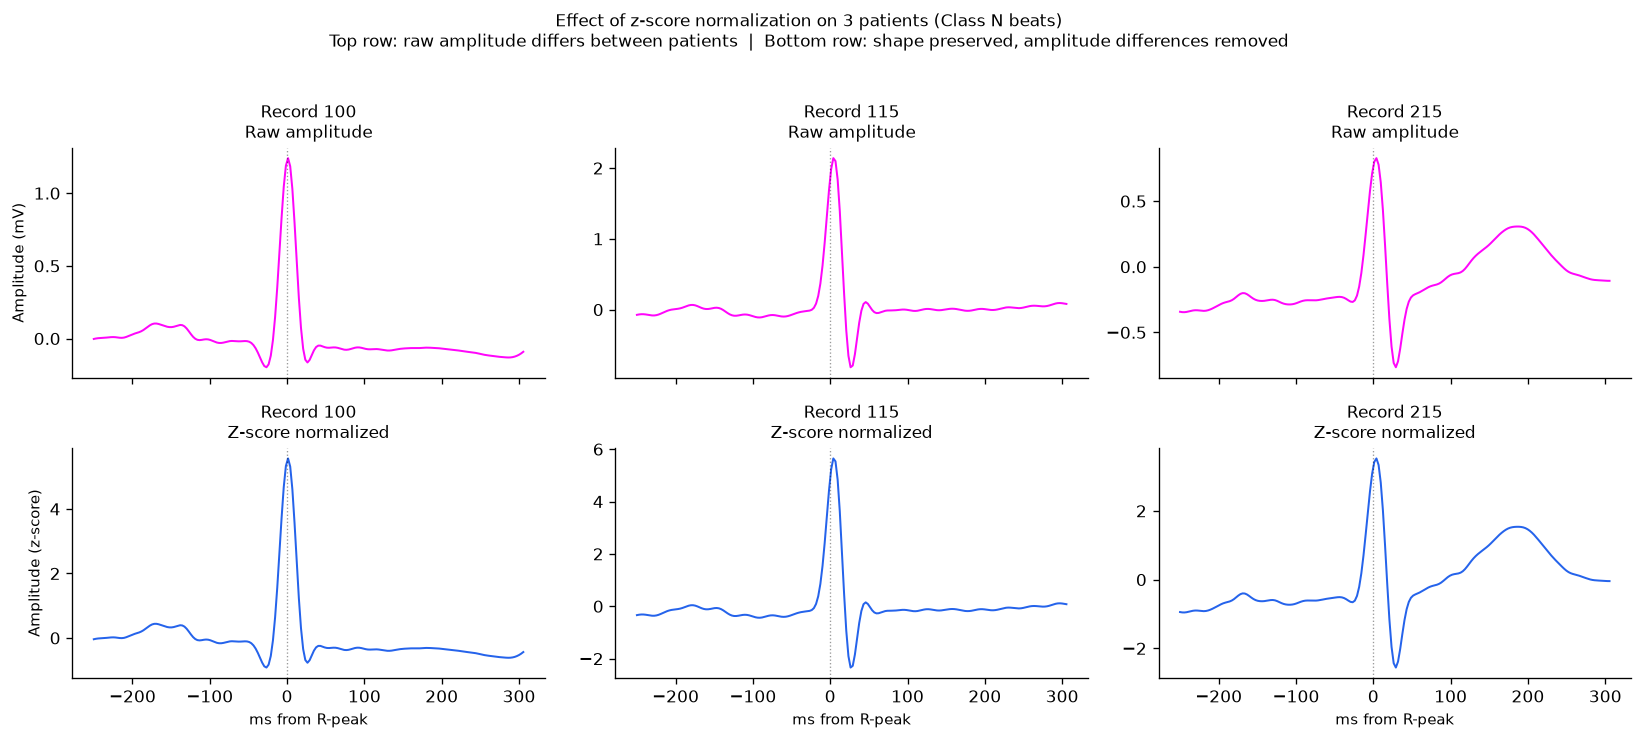

Key observation: after normalization, the three beats have the same
amplitude scale despite coming from patients with different ECG amplitudes.
The classifier will learn from shape, not from absolute amplitude.


In [8]:
# ── Visual demonstration of z-score normalization ──────────────────────────
# Compare the same beat before and after normalization to show that
# shape is preserved while amplitude differences are removed.
# We use 3 patients with visibly different R-peak amplitudes.

demo_records = ['100', '115', '215']
fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharex=True)
time_ms = np.linspace(-WINDOW_BEFORE/FS*1000, WINDOW_AFTER/FS*1000, BEAT_LENGTH)

for col, rec_name in enumerate(demo_records):
    rec = wfdb.rdrecord(DATA_PATH + rec_name)
    ann = wfdb.rdann(DATA_PATH + rec_name, 'atr')
    sig = bandpass_filter(rec.p_signal[:, 0], fs=rec.fs)

    # Find first normal beat
    for sample, symbol in zip(ann.sample, ann.symbol):
        if AAMI_MAP.get(symbol) == 'N':
            start = sample - WINDOW_BEFORE
            end   = sample + WINDOW_AFTER
            if start >= 0 and end <= len(sig):
                beat_raw = sig[start:end]
                break

    # Normalized version
    beat_norm = (beat_raw - beat_raw.mean()) / beat_raw.std()

    # Top row: raw beat
    axes[0, col].plot(time_ms, beat_raw, color='#FF06FB', linewidth=1.2)
    axes[0, col].set_title(f'Record {rec_name}\nRaw amplitude', fontsize=10)
    axes[0, col].set_ylabel('Amplitude (mV)' if col == 0 else '', fontsize=9)
    axes[0, col].axvline(0, color='black', linestyle=':', linewidth=0.8, alpha=0.4)

    # Bottom row: normalized beat
    axes[1, col].plot(time_ms, beat_norm, color='#2563EB', linewidth=1.2)
    axes[1, col].set_title(f'Record {rec_name}\nZ-score normalized', fontsize=10)
    axes[1, col].set_ylabel('Amplitude (z-score)' if col == 0 else '', fontsize=9)
    axes[1, col].set_xlabel('ms from R-peak', fontsize=9)
    axes[1, col].axvline(0, color='black', linestyle=':', linewidth=0.8, alpha=0.4)

fig.suptitle(
    'Effect of z-score normalization on 3 patients (Class N beats)\n'
    'Top row: raw amplitude differs between patients  |  '
    'Bottom row: shape preserved, amplitude differences removed',
    fontsize=10, y=1.02
)
plt.tight_layout()
plt.savefig('../results/figures/02_05_normalization_effect.png', bbox_inches='tight')
plt.show()

print("Key observation: after normalization, the three beats have the same")
print("amplitude scale despite coming from patients with different ECG amplitudes.")
print("The classifier will learn from shape, not from absolute amplitude.")

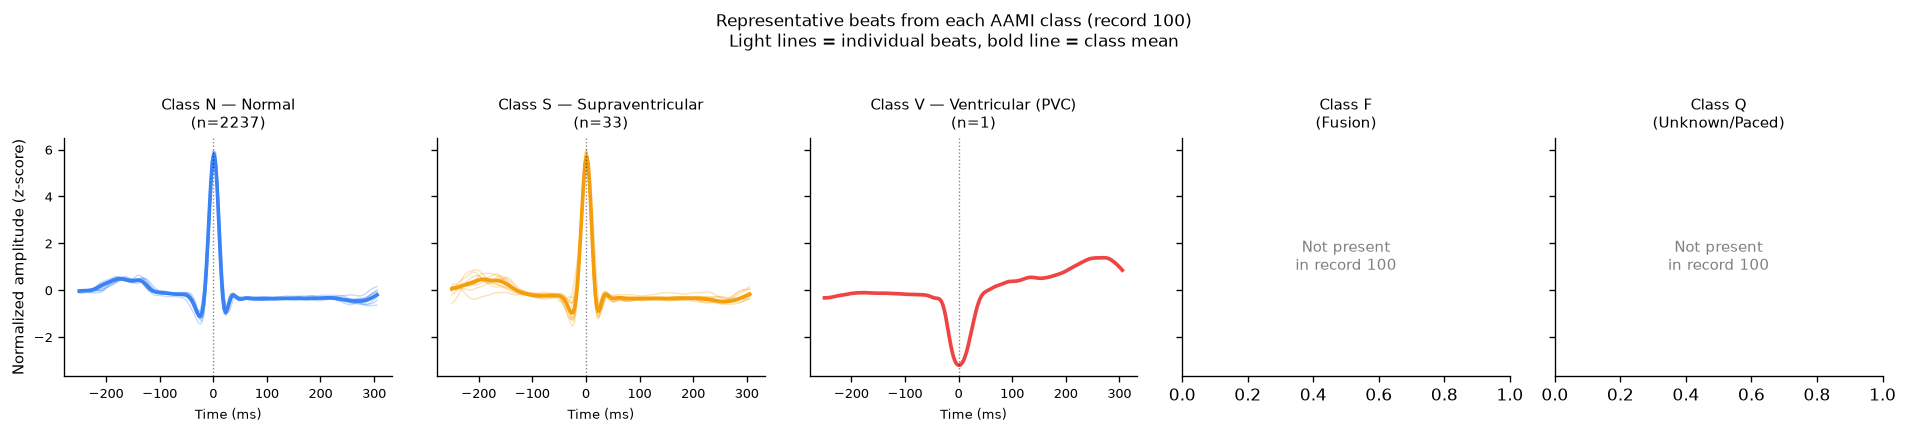

Observation: Class V (PVC) beats show visibly wider QRS complexes and inverted T-waves compared to Class N.
This morphological difference is what the classifier will learn to detect.


In [9]:
# Visualize representative beats from each AAMI class
fig, axes = plt.subplots(1, 5, figsize=(16, 3.5), sharey=True)
time_ms = np.linspace(-WINDOW_BEFORE/FS*1000, WINDOW_AFTER/FS*1000, BEAT_LENGTH)

for ax, cls in zip(axes, ['N', 'S', 'V', 'F', 'Q']):
    indices = [i for i, l in enumerate(labels_test) if l == cls]
    
    if len(indices) == 0:
        ax.text(0.5, 0.5, 'Not present\nin record 100', ha='center', va='center',
               transform=ax.transAxes, fontsize=9, color='gray')
        ax.set_title(f'Class {cls}\n({CLASS_NAMES[cls]})', fontsize=9)
        continue
    
    # Plot up to 10 example beats with low opacity to show variability
    for idx in indices[:10]:
        ax.plot(time_ms, beats_test[idx], color=CLASS_COLORS[cls], alpha=0.3, linewidth=0.8)
    
    # Plot the mean beat
    mean_beat = np.mean(beats_test[indices[:50]], axis=0)
    ax.plot(time_ms, mean_beat, color=CLASS_COLORS[cls], linewidth=2.2, label='Mean')
    ax.axvline(0, color='black', linestyle=':', linewidth=0.8, alpha=0.5)
    ax.set_title(f'Class {cls} — {CLASS_NAMES[cls]}\n(n={len(indices)})', fontsize=9)
    ax.set_xlabel('Time (ms)', fontsize=8)
    ax.tick_params(labelsize=8)

axes[0].set_ylabel('Normalized amplitude (z-score)', fontsize=9)
fig.suptitle('Representative beats from each AAMI class (record 100)\nLight lines = individual beats, bold line = class mean', 
             fontsize=10, y=1.02)
plt.tight_layout()
plt.savefig('../results/figures/02_05_aami_class_beats.png', bbox_inches='tight')
plt.show()
print("Observation: Class V (PVC) beats show visibly wider QRS complexes and inverted T-waves compared to Class N.")
print("This morphological difference is what the classifier will learn to detect.")

## 6. Full dataset preprocessing pipeline

We now apply the complete pipeline — filtering, segmentation, and
normalization — to all 48 records and produce the final train/test
arrays following the DS1/DS2 inter-patient split.

In [10]:
# ── DS1/DS2 inter-patient split from de Chazal et al. (2004) [1] ───────────–––––––––––––––
DS1_RECORDS = ['101','106','108','109','112','114','115','116','118','119','122','124','201','203','205','207','208','209','215','220','223','230']

DS2_RECORDS = ['100','103','105','111','113','117','121','123','200','202','210','212','213','214','219','221','222','228','231','232','233','234']
#–––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


print("Processing DS1 (training set)...")
X_train, y_train = process_record_list(DS1_RECORDS, DATA_PATH)

print("\nProcessing DS2 (test set)...")
X_test, y_test = process_record_list(DS2_RECORDS, DATA_PATH)

print(f"\n{'='*50}")
print(f"DS1 (train): {X_train.shape[0]:,} beats")
print(f"DS2 (test) : {X_test.shape[0]:,} beats")
print(f"Beat length: {X_train.shape[1]} samples")

Processing DS1 (training set)...

Processing DS2 (test set)...

DS1 (train): 51,008 beats
DS2 (test) : 49,697 beats
Beat length: 200 samples


### Why the split is manual and not random

The DS1/DS2 division is not arbitrary — it is the standard inter-patient
evaluation protocol defined in de Chazal et al. (2004) [[1]](#references) and used
in virtually all MIT-BIH classification papers published since.

A random split would be incorrect for two reasons:

**Data leakage:** a random beat-level split places beats from the same
patient in both training and test sets. The model learns patient-specific
ECG signatures rather than generalizable arrhythmia morphology, producing
inflated accuracy that does not reflect real-world performance on new patients.

**Reproducibility:** a fixed manual split ensures that results from
different research groups are directly comparable. This is analogous
to the fixed train/test splits used in ImageNet or MNIST benchmarks.

The specific records in DS1 and DS2 were chosen to ensure that minority
classes (F, Q) are represented in both sets, avoiding the risk of
a random split concentrating all rare-class records in one partition.

## 7. Class distribution analysis

In Notebook 01 we analyzed the global class distribution across all
48 records. Here we repeat the analysis **separately for DS1 and DS2**
to verify two things:

- Both sets preserve the global imbalance ratio — if one set had a
  very different distribution, the model would be trained and tested
  on structurally different data
- Minority classes (F, Q) are represented in both sets — a random
  split could accidentally concentrate all rare-class records in one
  partition, making learning or evaluation impossible

This verification is a mandatory sanity check before any modeling.

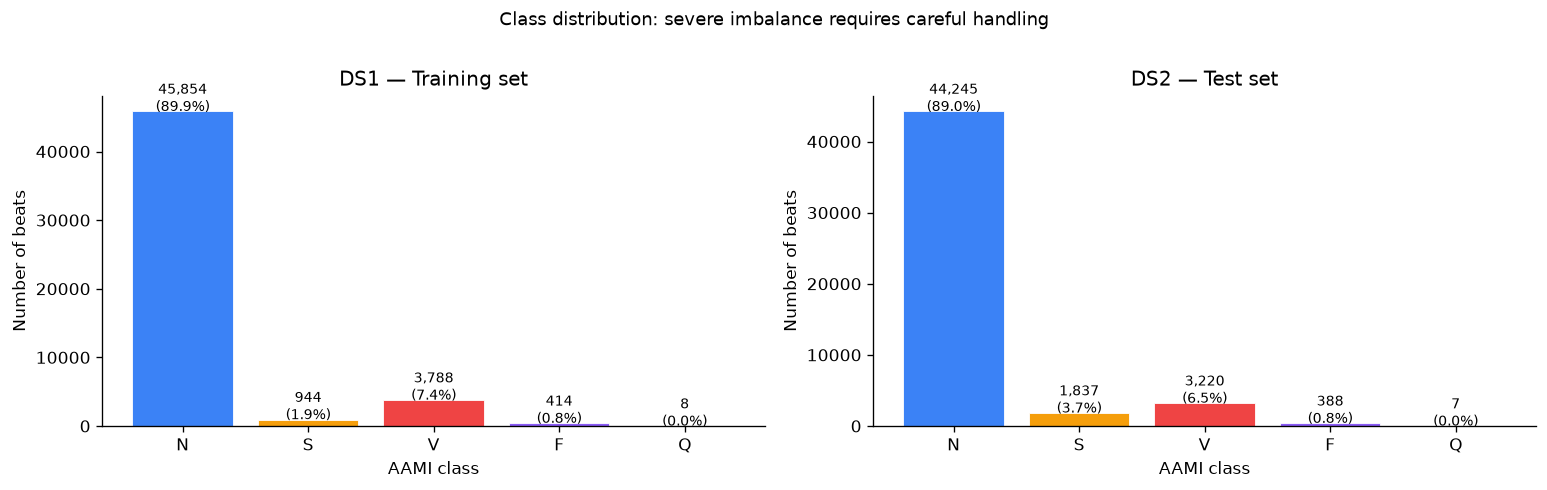

Imbalance ratio (N vs Q): 5732:1

Implication: a naive classifier predicting 'N' for everything would achieve
89.9% accuracy — which is clinically useless.
This is why we will use F1-macro and per-class recall as our primary metrics, not accuracy.


In [11]:
from collections import Counter

train_counts = Counter(y_train)
test_counts = Counter(y_test)

classes = ['N', 'S', 'V', 'F', 'Q']
train_vals = [train_counts.get(c, 0) for c in classes]
test_vals = [test_counts.get(c, 0) for c in classes]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, vals, title in zip(axes, [train_vals, test_vals], ['DS1 — Training set', 'DS2 — Test set']):
    bars = ax.bar(classes, vals, color=[CLASS_COLORS[c] for c in classes], 
                  edgecolor='white', linewidth=0.5)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Number of beats')
    ax.set_xlabel('AAMI class')
    total = sum(vals)
    for bar, val in zip(bars, vals):
        pct = val / total * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=8.5)

plt.suptitle('Class distribution: severe imbalance requires careful handling', 
             fontsize=11, fontweight='normal', y=1.01)
plt.tight_layout()
plt.savefig('../results/figures/02_07_class_distribution_ds1_ds2.png', bbox_inches='tight')
plt.show()

# Imbalance ratio
max_class = max(train_counts, key=train_counts.get)
min_class = min(train_counts, key=train_counts.get)
ratio = train_counts[max_class] / train_counts[min_class]
print(f"Imbalance ratio (N vs Q): {ratio:.0f}:1")
print()
print("Implication: a naive classifier predicting 'N' for everything would achieve")
print(f"{train_counts['N']/sum(train_vals)*100:.1f}% accuracy — which is clinically useless.")
print("This is why we will use F1-macro and per-class recall as our primary metrics, not accuracy.")

### Interpreting the distribution

The two bar charts should show a similar imbalance pattern — class N
dominant in both, minority classes present in both. If the distributions
looked very different between DS1 and DS2, it would indicate a problem
with the split.

The imbalance ratio computed above confirms what we established in
Notebook 01: a naive classifier predicting N for everything achieves
high accuracy while detecting zero arrhythmias. This is why we will use:

- **F1-macro** as the primary metric — weights all classes equally
- **Per-class recall** as secondary, especially for class V — a false
  negative on a PVC has clinical consequences
- **`class_weight='balanced'`** in all scikit-learn models in Notebook 04
- **SMOTE** applied to the training set only (never to test set)

## 8. Summary and next steps

### What we accomplished in this notebook

1. Designed and validated a zero-phase Butterworth bandpass filter (0.5–40 Hz) appropriate for ECG signals, with visual verification of its frequency response.
2. Segmented all 48 MIT-BIH records into individual beat windows using the AAMI EC57 standard label mapping, with per-beat z-score normalization.
3. Applied the clinically correct **inter-patient split** (DS1/DS2) to prevent data leakage.
4. Quantified the class imbalance and established that accuracy is not an appropriate evaluation metric for this task.

---

### Key methodological decisions and their justifications

| Decision | Rationale |
|---|---|
| Butterworth filter (not Chebyshev) | Flat passband avoids R-peak amplitude distortion |
| filtfilt (not lfilter) | Zero-phase shift preserves R-peak timing |
| Window 90+110 samples | Captures full P-QRS-T at HR up to ~100 bpm |
| AAMI EC57 grouping | Clinically validated standard; enables literature comparison |
| Inter-patient split (DS1/DS2) | Prevents data leakage; tests true generalization |
| Per-beat z-score normalization | Removes amplitude bias; forces morphology-based classification |
| F1-macro as primary metric | Penalizes equally for errors in minority classes (V, F, Q) |

---

### Output of this notebook

The preprocessing pipeline produces a single compressed file:

**`data/processed_beats.npz`** containing:

| Array | Shape | Description |
|---|---|---|
| `X_train` | (n_beats_DS1, 200) | Normalized beat matrix for training |
| `y_train` | (n_beats_DS1,) | AAMI class labels for training |
| `X_test` | (n_beats_DS2, 200) | Normalized beat matrix for test |
| `y_test` | (n_beats_DS2,) | AAMI class labels for test |

This file is the input to Notebooks 03, 04, and 05. It is not
included in the repository (listed in `.gitignore`) because it can
be fully reproduced by running this notebook.

---

### Figures produced in this notebook

| Figure file | Section | What it shows |
|---|---|---|
| `02_02_filter_response.png` | 2 | Butterworth bandpass frequency response |
| `02_03_raw_vs_filtered.png` | 3 | Raw vs filtered ECG — baseline wander removal |
| `02_05_segmentation_windows.png` | 5 | Beat windows overlaid on filtered signal |
| `02_05_normalization_effect.png` | 5 | Z-score normalization across 3 patients |
| `02_05_aami_class_beats.png` | 5 | Representative beats per AAMI class |
| `02_07_class_distribution_ds1_ds2.png` | 7 | Class distribution in DS1 and DS2 |

---

### Next notebook

**Notebook 03 — Feature Extraction:** Extract 20 temporal and spectral features from each beat for use with classical ML models (Random Forest, SVM, MLP).

<h1 id="references">References</h1>



[1] P. de Chazal, M. O'Dwyer, and R. B. Reilly, "Automatic classification of heartbeats using ECG morphology and heartbeat interval features," *IEEE Transactions on Biomedical Engineering*, vol. 51, no. 7, pp. 1196–1206, Jul. 2004, doi: 10.1109/TBME.2004.827359.

[2] A. L. Goldberger, Z. D. Goldberger, and A. Shvilkin, *Goldberger's Clinical Electrocardiography: A Simplified Approach*, 9th ed. Philadelphia, PA: Elsevier, 2017.

[3] P. S. Hamilton and W. J. Tompkins, "Quantitative investigation of QRS detection rules using the MIT/BIH arrhythmia database," *IEEE Transactions on Biomedical Engineering*, vol. 33, no. 12, pp. 1157–1165, Dec. 1986, doi: 10.1109/TBME.1986.325695.

[4] A. V. Oppenheim and R. W. Schafer, *Discrete-Time Signal Processing*, 3rd ed. Upper Saddle River, NJ: Prentice Hall, 2009.

[5] Association for the Advancement of Medical Instrumentation, *Testing and Reporting Performance Results of Cardiac Rhythm and ST Segment Measurement Algorithms*, AAMI EC57, Arlington, VA, 1998.